In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
X

array([[-8.23020845,  0.10304368],
       [ 9.74055177, -2.73921197],
       [-2.72849037,  2.68354043],
       ...,
       [-4.88306053,  3.32367617],
       [-4.48840942,  3.07140354],
       [-6.82167361,  0.71130834]])

In [6]:
np.unique(y)

array([0, 1, 2])

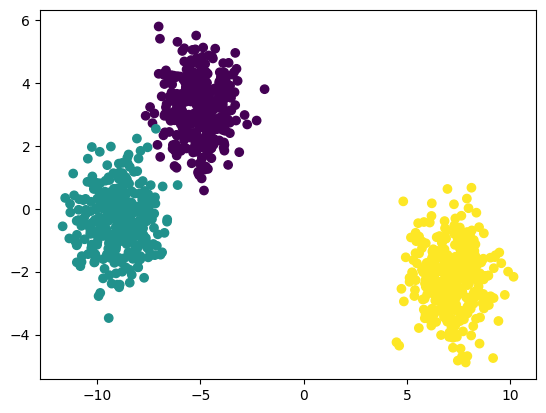

In [7]:
plt.scatter(X[:,0],X[:,1],c=y)

In [8]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [11]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [12]:
from sklearn.cluster import KMeans

In [13]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

/home/mrx/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/mrx/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/mrx/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/mrx/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default 

In [14]:
wcss

[1340.0000000000002,
 394.8020786138891,
 116.49596657557635,
 91.33530553910924,
 68.301760398887,
 51.2303080546283,
 44.15397019233058,
 38.062192601180655,
 33.47624596722096,
 30.29865356771439]

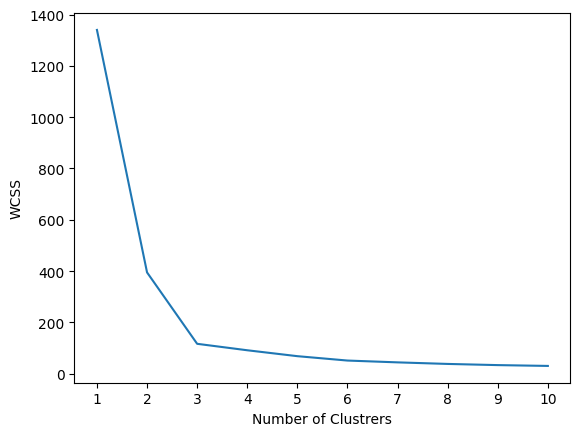

In [15]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [16]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [17]:
kmeans.fit_predict(X_train_scaled)

/home/mrx/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


array([2, 1, 2, 0, 2, 2, 0, 0, 0, 2, 0, 1, 0, 1, 2, 0, 1, 2, 2, 1, 1, 0,
       0, 1, 1, 0, 1, 2, 0, 0, 1, 2, 1, 1, 1, 0, 2, 0, 1, 2, 2, 0, 0, 0,
       1, 1, 2, 1, 0, 2, 0, 2, 0, 2, 2, 2, 1, 0, 1, 2, 2, 1, 0, 2, 2, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 1, 2, 0,
       0, 0, 0, 0, 2, 1, 2, 1, 0, 0, 2, 2, 0, 2, 0, 2, 2, 0, 1, 1, 1, 1,
       1, 0, 1, 2, 2, 2, 0, 1, 0, 0, 0, 2, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 0, 0, 0, 1, 0, 1, 2, 2, 2,
       1, 1, 1, 2, 0, 0, 2, 1, 0, 2, 2, 2, 1, 0, 1, 2, 0, 1, 1, 1, 1, 2,
       2, 1, 2, 1, 1, 2, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 2, 0, 0, 2,
       1, 1, 0, 1, 0, 0, 2, 0, 0, 0, 2, 0, 1, 2, 2, 2, 1, 1, 1, 0, 1, 0,
       2, 0, 1, 0, 0, 1, 2, 0, 2, 0, 1, 2, 2, 0, 2, 2, 0, 2, 2, 0, 0, 1,
       1, 1, 1, 2, 1, 2, 2, 0, 0, 0, 2, 0, 1, 0, 0, 2, 0, 2, 2, 0, 2, 2,
       1, 1, 1, 2, 0, 1, 1, 0, 2, 1, 1, 0, 2, 2, 0, 1, 2, 2, 2, 1, 1, 1,
       2, 0, 0, 1, 1, 0, 2, 2, 1, 0, 1, 1, 0, 2, 1,

In [18]:
y_pred=kmeans.predict(X_test_scaled)

In [22]:
y_pred

array([2, 2, 2, 0, 1, 1, 2, 0, 0, 2, 1, 2, 1, 2, 1, 0, 0, 1, 2, 0, 0, 1,
       0, 0, 0, 0, 2, 2, 0, 0, 2, 0, 1, 1, 1, 1, 0, 0, 0, 2, 1, 2, 1, 2,
       2, 1, 1, 0, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 1, 2,
       2, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 2, 0, 0, 2, 0, 2, 2, 1, 0, 2, 1,
       2, 0, 1, 0, 1, 0, 2, 1, 1, 2, 2, 1, 0, 0, 0, 2, 1, 0, 1, 2, 2, 1,
       1, 1, 0, 2, 2, 0, 1, 1, 1, 2, 2, 2, 2, 1, 0, 0, 2, 1, 2, 1, 2, 2,
       2, 1, 1, 1, 1, 1, 2, 2, 0, 1, 2, 0, 2, 2, 2, 1, 1, 0, 1, 1, 0, 1,
       0, 2, 0, 2, 1, 1, 2, 1, 2, 0, 1, 2, 0, 2, 2, 0, 2, 1, 1, 0, 2, 2,
       2, 2, 0, 0, 0, 0, 2, 2, 1, 1, 0, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 2,
       1, 1, 2, 0, 2, 0, 1, 1, 2, 1, 2, 1, 2, 1, 0, 2, 2, 2, 2, 2, 1, 2,
       0, 0, 2, 2, 2, 2, 2, 2, 1, 2, 0, 2, 0, 1, 1, 1, 1, 0, 2, 2, 0, 2,
       2, 1, 0, 2, 2, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 1, 0, 0, 0, 1, 1,
       0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 1, 2, 1, 0, 1, 1, 1, 0, 2, 0, 1, 1,
       0, 0, 2, 0, 0, 1, 2, 1, 2, 2, 1, 1, 2, 0, 1,

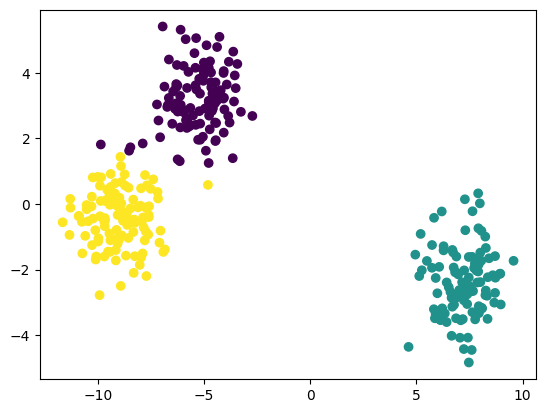

In [19]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [20]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [21]:
## kneelocator
!pip install kneed

In [22]:
from kneed import KneeLocator

In [23]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [24]:
kl.elbow

3

In [25]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [26]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

/home/mrx/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/mrx/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/mrx/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/mrx/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default 

In [27]:
silhouette_coefficients

[0.6701147563052913,
 0.7116932828870987,
 0.6177588829276637,
 0.5018190955305809,
 0.4520618156121398,
 0.44139758613175223,
 0.40817009435981977,
 0.40307644028330153,
 0.3844257362781622]

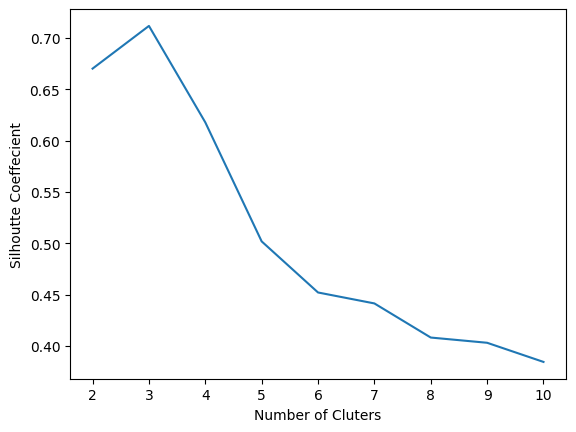

In [28]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()